In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\placement_predict_50k Dataset_final.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [3]:
placed_df = df[df["Salary Package"] > 0].copy()

print("Placed students:", len(placed_df))

Placed students: 32924


In [4]:
X = placed_df[["CGPA"]]
y = placed_df["Salary Package"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26339, 1)
X_test : (6585, 1)
y_train: (26339,)
y_test : (6585,)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original CGPA:")
print(X_train.head())

print("\nStandardized CGPA:")
print(X_train_scaled[:5])

Original CGPA:
        CGPA
40542  10.00
44517   8.18
20861   6.25
3480    9.15
11151   7.42

Standardized CGPA:
[[ 1.54661158]
 [ 0.13512655]
 [-1.36166801]
 [ 0.88740154]
 [-0.45428478]]


In [6]:
#Batch Gradient Descent from scratch

# Convert to NumPy arrays
X_gd = X_train_scaled.flatten()
y_gd = y_train.to_numpy()

m = len(X_gd)

# Initialize parameters
theta_0 = 0.0
theta_1 = 0.0

learning_rate = 0.01
epochs = 1000

loss_history = []

# ------------------------------------------------------------
# Batch Gradient Descent
# ------------------------------------------------------------
for epoch in range(epochs):

    # Prediction
    y_pred = theta_0 + theta_1 * X_gd
    print(" theta_0:", theta_0)
    print(" theta_1:", theta_1)

    # Error
    error = y_pred - y_gd

    # MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)

    # Gradients
    gradient_theta_0 = (2 / m) * np.sum(error)
    gradient_theta_1 = (2 / m) * np.sum(error * X_gd)

    # Parameter update
    theta_0 -= learning_rate * gradient_theta_0
    theta_1 -= learning_rate * gradient_theta_1

print("Final theta_0:", theta_0)
print("Final theta_1:", theta_1)
print("Final training MSE:", loss_history[-1])

 theta_0: 0.0
 theta_1: 0.0
 theta_0: 0.2897377121378944
 theta_1: 0.10599093990444651
 theta_0: 0.5736806700330309
 theta_1: 0.2098620610108041
 theta_0: 0.8519447687702648
 theta_1: 0.3116557596950345
 theta_0: 1.124643585532754
 theta_1: 0.4114135844055803
 theta_0: 1.3918884259599933
 theta_1: 0.5091762526219152
 theta_0: 1.653788369578688
 theta_1: 0.6049836674739234
 theta_0: 1.9104503143250087
 theta_1: 0.6988749340288914
 theta_0: 2.161979020176403
 theta_1: 0.7908883752527601
 theta_0: 2.4084771519107693
 theta_1: 0.8810615476521514
 theta_0: 2.6500453210104484
 theta_1: 0.9694312566035549
 theta_0: 2.886782126728134
 theta_1: 1.0560335713759303
 theta_0: 3.1187841963314655
 theta_1: 1.1409038398528581
 theta_0: 3.3461462245427307
 theta_1: 1.2240767029602475
 theta_0: 3.5689610121897704
 theta_1: 1.305586108805489
 theta_0: 3.7873195040838694
 theta_1: 1.3854653265338257
 theta_0: 4.001310826140086
 theta_1: 1.4637469599075956
 theta_0: 4.211022321755179
 theta_1: 1.540462960

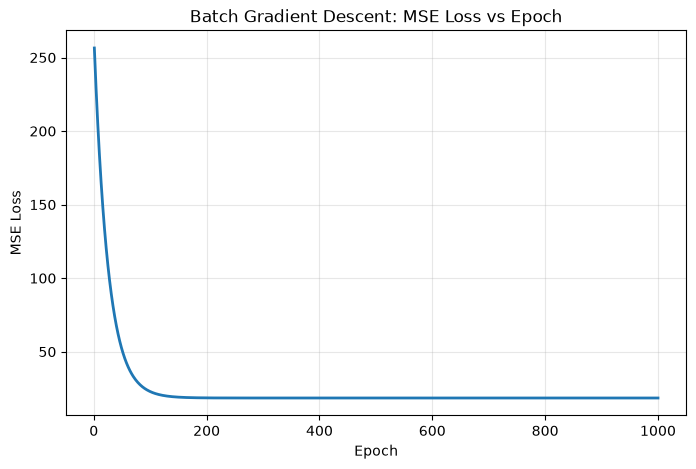

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent: MSE Loss vs Epoch")
plt.grid(True, alpha=0.3)

plt.show()

In [8]:
X_test_gd = X_test_scaled.flatten()

y_test_pred_gd = theta_0 + theta_1 * X_test_gd

gd_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_gd)
)

gd_mae = mean_absolute_error(
    y_test,
    y_test_pred_gd
)

gd_r2 = r2_score(
    y_test,
    y_test_pred_gd
)

print("Batch GD RMSE:", gd_rmse)
print("Batch GD MAE :", gd_mae)
print("Batch GD R²  :", gd_r2)

Batch GD RMSE: 4.278633635327304
Batch GD MAE : 3.384857301464024
Batch GD R²  : 0.6080779825589153
